In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
website = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE169nnn/GSE169598/matrix/GSE169598_series_matrix.txt.gz"
data_path = "fajciarky_data/data.txt"
data_path_zip = "fajciarky_data/data.txt.gz"

In [3]:
# !curl $website --create-dirs -o $data_path_zip
# !gunzip $data_path_zip

In [4]:
skiprow = None

with open(data_path, "r") as f:

    for i, line in enumerate(f):

        if line.startswith("\"ID_REF\""):
            skiprow = i
            break

print("Table starts at row:", skiprow)

Table starts at row: 64


In [5]:
df = pd.read_csv(
    data_path,
    sep="\t",
    comment="!",
    header=0,
    skiprows=skiprow
)

df.set_index("ID_REF", inplace=True)

print("\nOriginal shape:")
print(df.shape)


Original shape:
(714666, 96)


In [6]:
print("\nFirst rows:")
print(df.head())



First rows:
            GSM5210464  GSM5210465  GSM5210466  GSM5210467  GSM5210468  \
ID_REF                                                                   
cg00000029    0.006342    0.101510    0.042916    0.101567    0.114736   
cg00000109    0.911428    0.924547    0.926018    0.920207    0.925702   
cg00000155    0.948963    0.936607    0.946371    0.951434    0.949158   
cg00000158    0.955034    0.954614    0.964843    0.958018    0.954761   
cg00000165    0.602739    0.654239    0.635608    0.514626    0.569226   

            GSM5210469  GSM5210470  GSM5210471  GSM5210472  GSM5210473  ...  \
ID_REF                                                                  ...   
cg00000029    0.129332    0.134621    0.105126    0.116374    0.115263  ...   
cg00000109    0.920111    0.928904    0.930301    0.936867    0.929511  ...   
cg00000155    0.941937    0.940608    0.952269    0.940826    0.945244  ...   
cg00000158    0.952986    0.948309    0.949837    0.964955    0.958335  .

In [7]:
df = df.astype(float)

df = df.T

print("\nTransposed shape:")
print(df.shape)


Transposed shape:
(96, 714666)


In [8]:
metadata = {}

with open(data_path, "r") as file:

    characteristic_counter = 0

    for line in file:
        if line.startswith("!Sample_title"):

            metadata["title"] = line.strip().split("\t")[1:]
        elif line.startswith("!Sample_geo_accession"):

            metadata["accession"] = line.strip().split("\t")[1:]
        elif line.startswith("!Sample_characteristics_ch1"):

            values = line.strip().split("\t")[1:]
            
            if characteristic_counter == 0:
                metadata["sex"] = values
            elif characteristic_counter == 1:
                metadata["gestational_age"] = values
            elif characteristic_counter == 2:
                metadata["smoke_type"] = values

            characteristic_counter += 1
        elif line.startswith("!series_matrix_table_begin"):
            break

meta_df = pd.DataFrame(metadata)
# meta_df = meta_df.applymap(lambda x: x.replace('"', ''))
meta_df = meta_df.apply(lambda s: s.str.replace('"', '', regex=False))
print(meta_df.columns)

Index(['title', 'accession', 'sex', 'gestational_age', 'smoke_type'], dtype='str')


In [9]:
print(meta_df.head())


             title   accession     sex              gestational_age  \
0  placental DNA 1  GSM5210464  Sex: F  gestational age weeks: 39.4   
1  placental DNA 2  GSM5210465  Sex: F  gestational age weeks: 39.3   
2  placental DNA 3  GSM5210466  Sex: F  gestational age weeks: 39.3   
3  placental DNA 4  GSM5210467  Sex: M  gestational age weeks: 39.7   
4  placental DNA 5  GSM5210468  Sex: F  gestational age weeks: 37.7   

           smoke_type  
0  smoking: nonsmoker  
1     smoking: smoker  
2  smoking: nonsmoker  
3     smoking: smoker  
4     smoking: smoker  


In [10]:
def create_label(smoke_value):

    value = smoke_value.lower()

    if "nonsmoker" in value:
        return "NonSmoker"

    elif "smoker" in value:
        return "Smoker"

    else:
        return "Unknown"
    
meta_df["label"] = meta_df["smoke_type"].apply(create_label)

print("\nLabel counts:")
print(meta_df["label"].value_counts())


Label counts:
label
Smoker       72
NonSmoker    24
Name: count, dtype: int64


In [11]:
meta_df = meta_df.set_index("accession")

y = meta_df.loc[df.index, "label"]

X = df.copy()

print(X.shape)
print(y.value_counts())

(96, 714666)
label
Smoker       72
NonSmoker    24
Name: count, dtype: int64


In [12]:
nan_frac = X.isna().mean(axis=0)
# print how many probes have any missingness
print(f'any missingness: {(nan_frac > 0).sum():,}')

any missingness: 0


In [13]:
meta_df

,title,sex,gestational_age,smoke_type,label
accession,,,,,
GSM5210464,placental DNA 1,Sex: F,gestational age weeks: 39.4,smoking: nonsmoker,NonSmoker
GSM5210465,placental DNA 2,Sex: F,gestational age weeks: 39.3,smoking: smoker,Smoker
GSM5210466,placental DNA 3,Sex: F,gestational age weeks: 39.3,smoking: nonsmoker,NonSmoker
GSM5210467,placental DNA 4,Sex: M,gestational age weeks: 39.7,smoking: smoker,Smoker
GSM5210468,placental DNA 5,Sex: F,gestational age weeks: 37.7,smoking: smoker,Smoker
...,...,...,...,...,...
GSM5210564,placental DNA 92,Sex: F,gestational age weeks: 37.0,smoking: smoker,Smoker
GSM5210565,placental DNA 93,Sex: F,gestational age weeks: 37.9,smoking: smoker,Smoker
GSM5210566,placental DNA 94,Sex: F,gestational age weeks: 39.0,smoking: smoker,Smoker


In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
meta_df_train = meta_df.loc[X_train.index]
meta_df_test = meta_df.loc[X_test.index]

In [15]:
variances = X.var(axis=0)

In [16]:
# 1. compute variances ONLY on training data
variances = X_train.var(axis=0)

# 2. select top-k features based on training set only
top_k = 20_000
top_features = variances.sort_values(ascending=False).head(top_k).index

# 3. filter both train and test using SAME features
X_train_filtered = X_train[top_features]
X_test_filtered = X_test[top_features]

print("\nAfter feature filtering:")
print("Train shape:", X_train_filtered.shape)
print("Test shape:", X_test_filtered.shape)


After feature filtering:
Train shape: (76, 20000)
Test shape: (20, 20000)


In [17]:
# from sklearn.feature_selection import SequentialFeatureSelector
# from sklearn.linear_model import LogisticRegression

# model = LogisticRegression(max_iter=2000)

# sfs = SequentialFeatureSelector(
#     model,
#     n_features_to_select=50,
#     direction="forward",
#     scoring="accuracy",
#     cv=3 
# )


# sfs.fit(X_train_filtered, y_train)

# X_train_sequential = sfs.transform(X_train_filtered)
# X_test_sequential = sfs.transform(X_test_filtered)


# print("Selected shape:", X_train_sequential.shape)

In [18]:
from sklearn.feature_selection import SelectKBest, f_classif
import pandas as pd

selector = SelectKBest(score_func=f_classif, k=100)

# fit ONLY on training data
X_train_kbest_np = selector.fit_transform(X_train_filtered, y_train)
X_test_kbest_np = selector.transform(X_test_filtered)

# get selected column names
selected_columns = X_train_filtered.columns[selector.get_support()]

# convert back to DataFrames with original indices + column names
X_train_kbest = pd.DataFrame(
    X_train_kbest_np,
    index=X_train_filtered.index,
    columns=selected_columns
)

X_test_kbest = pd.DataFrame(
    X_test_kbest_np,
    index=X_test_filtered.index,
    columns=selected_columns
)

print("KBest shape:", X_train_kbest.shape)

KBest shape: (76, 100)


# PCA KOKOTINY

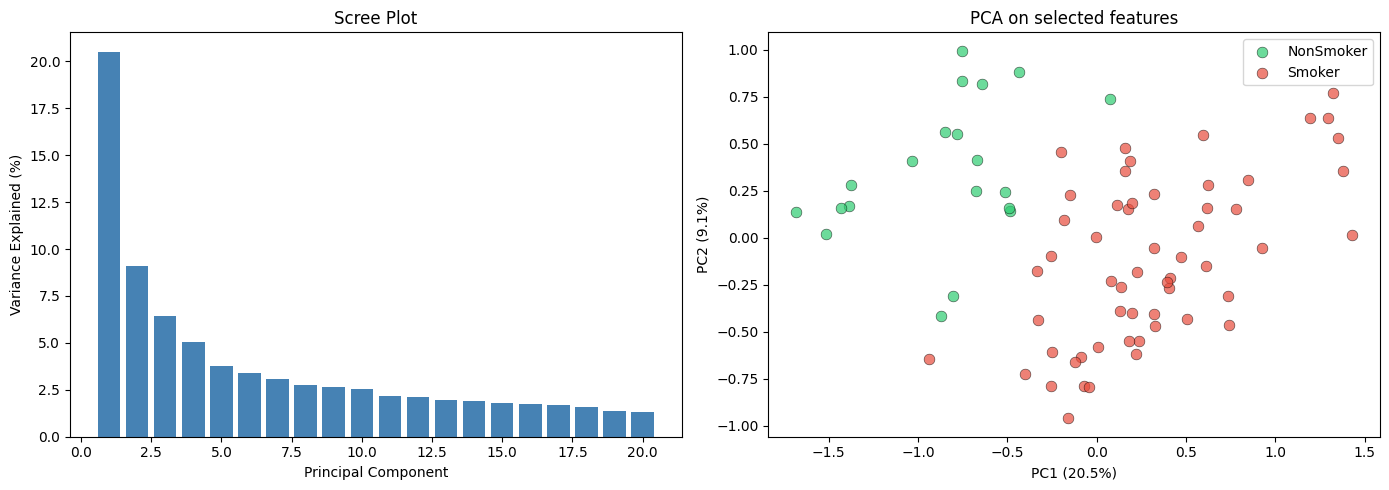

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=20, random_state=42)
#pca = PCA(n_components=0.95, random_state=42)
#PCs = pca.fit_transform(X_selected)
PCs = pca.fit_transform(X_train_kbest)
#TODO PCs_test = pca.transform(X_test_kbest)

#scree
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
#fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

axes[0].bar(range(1, 21), pca.explained_variance_ratio_ * 100, color='steelblue')
#axes[0].bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_ * 100, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot')

#pc1 vs pc2
colors = {'Smoker': '#e74c3c', 'NonSmoker': '#2ecc71'}
#for label, grp in pd.DataFrame({'PC1': PCs[:,0], 'PC2': PCs[:,1], 'label': y.values}).groupby('label'):
 #   axes[1].scatter(grp['PC1'], grp['PC2'], label=label,
  #                  color=colors[label], alpha=0.7, edgecolors='k', linewidths=0.4, s=60)
for label, grp in pd.DataFrame({'PC1': PCs[:,0], 'PC2': PCs[:,1], 'label': y_train.values}).groupby('label'):
    axes[1].scatter(grp['PC1'], grp['PC2'], label=label,
                    color=colors[label], alpha=0.7, edgecolors='k', linewidths=0.4, s=60)
    
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('PCA on selected features')

axes[1].legend()

plt.tight_layout()
plt.show()

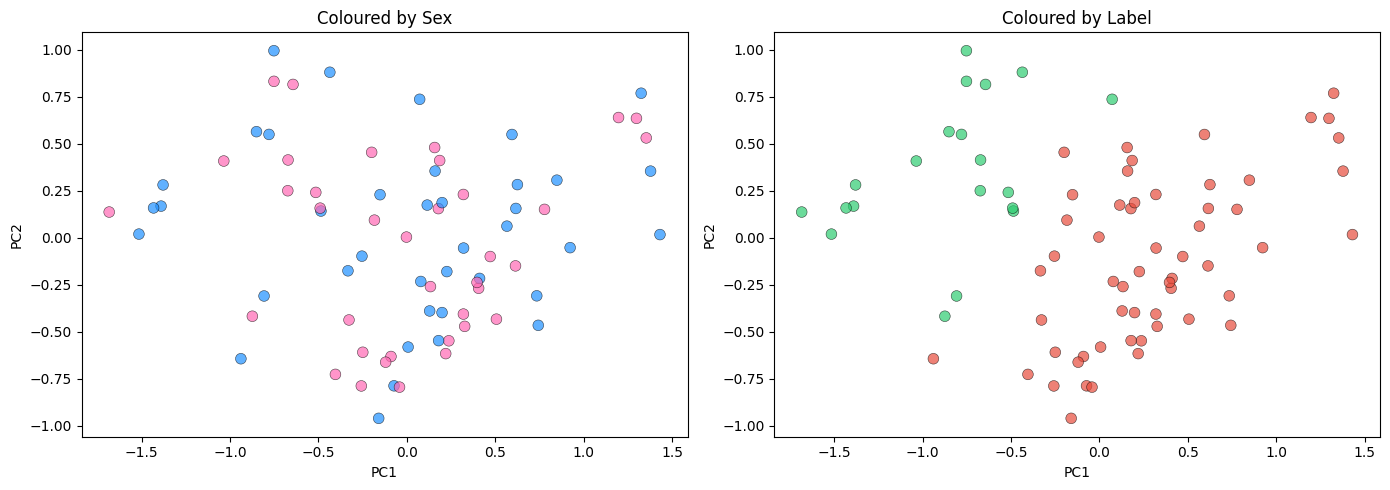

/COMP.TMP/brocekp_91961/ipykernel_34345/1378240965.py:26: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(PCs[:,0], PCs[:,1], c=col, alpha=0.7, edgecolors='k', linewidths=0.4, s=60, cmap='viridis')


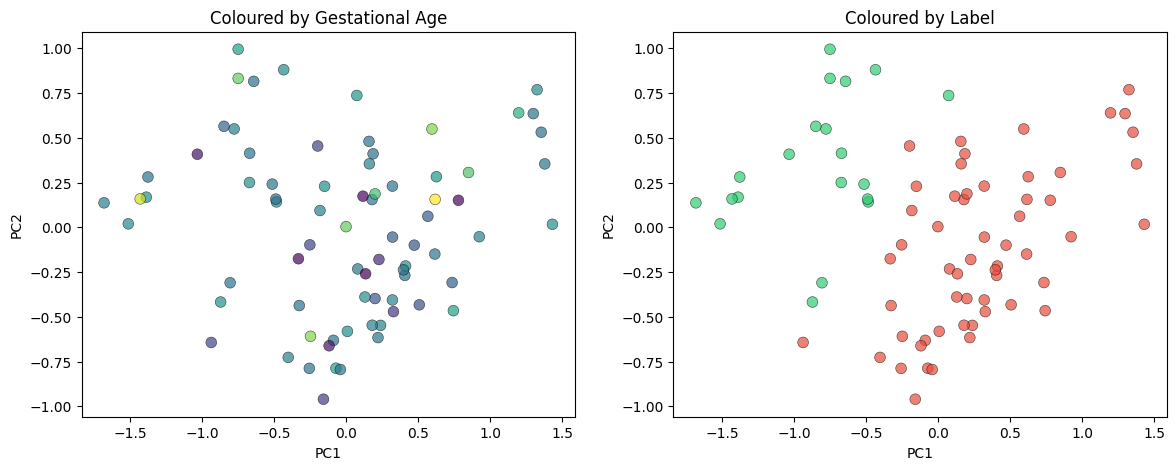

In [20]:
sex_col = meta_df.loc[X_train.index, 'sex'].map({
    'Sex: F': 'hotpink',
    'Sex: M': 'dodgerblue'
})
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(axes,
                           [sex_col.values, None],
                           ['Coloured by Sex', 'Coloured by Label']):
    if col is None:
        col = [colors[l] for l in y_train.loc[X_train.index]]
    ax.scatter(PCs[:,0], PCs[:,1], c=col, alpha=0.7, edgecolors='k', linewidths=0.4, s=60)
    ax.set_xlabel(f'PC1'); ax.set_ylabel('PC2'); ax.set_title(title)
plt.tight_layout()
plt.show()

#by gestational age
age_col = meta_df.loc[X_train.index, 'gestational_age'].map(
    lambda x: float(x.split(': ')[1].replace(' weeks', ''))
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(axes,
                           [age_col.values, None],
                           ['Coloured by Gestational Age', 'Coloured by Label']):
    if col is None:
        col = [colors[l] for l in y_train.loc[X_train.index]]
    scatter = ax.scatter(PCs[:,0], PCs[:,1], c=col, alpha=0.7, edgecolors='k', linewidths=0.4, s=60, cmap='viridis')
    ax.set_xlabel(f'PC1'); ax.set_ylabel('PC2'); ax.set_title(title)
    if col is age_col.values:
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Gestational Age (weeks)')

# RANDOM FORESTS

In [21]:
X_train = X_train_kbest.copy()
X_test = X_test_kbest.copy()

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)#, class_weight='balanced')

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Train Accuracy: 1.0
Test Accuracy: 0.9

Classification Report:
               precision    recall  f1-score   support

   NonSmoker       1.00      0.50      0.67         4
      Smoker       0.89      1.00      0.94        16

    accuracy                           0.90        20
   macro avg       0.94      0.75      0.80        20
weighted avg       0.91      0.90      0.89        20


Confusion Matrix:
 [[ 2  2]
 [ 0 16]]


In [22]:
importances = model.feature_importances_

feature_names = X_train_filtered.columns[selector.get_support()]

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print(feat_imp.head(10))

       feature  importance
34  cg27402634    0.147074
36  cg24714864    0.037713
83  cg26668911    0.032591
88  cg15605704    0.031303
64  cg07743644    0.030207
72  cg01485177    0.028908
43  cg11775807    0.021171
90  cg15412759    0.020230
33  cg08931687    0.019630
8   cg27119456    0.019194


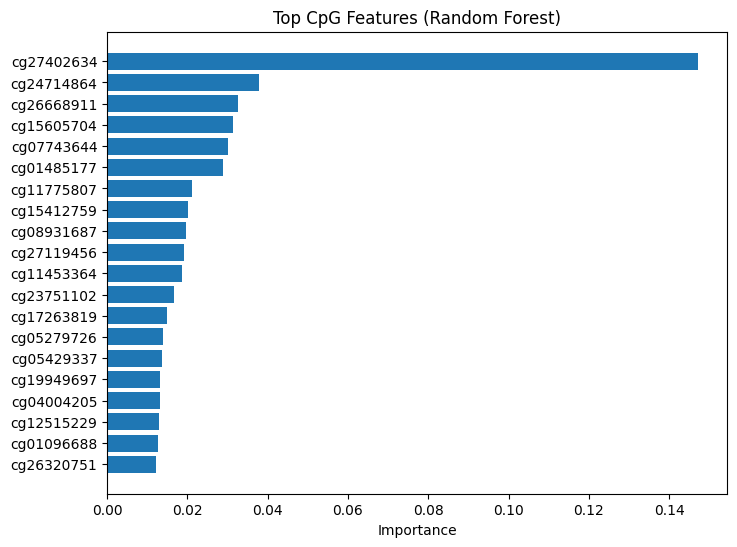

In [23]:
import matplotlib.pyplot as plt

top = feat_imp.head(20)

plt.figure(figsize=(8,6))
plt.barh(top["feature"][::-1], top["importance"][::-1])
plt.xlabel("Importance")
plt.title("Top CpG Features (Random Forest)")
plt.show()

## Foresty - ROC curve

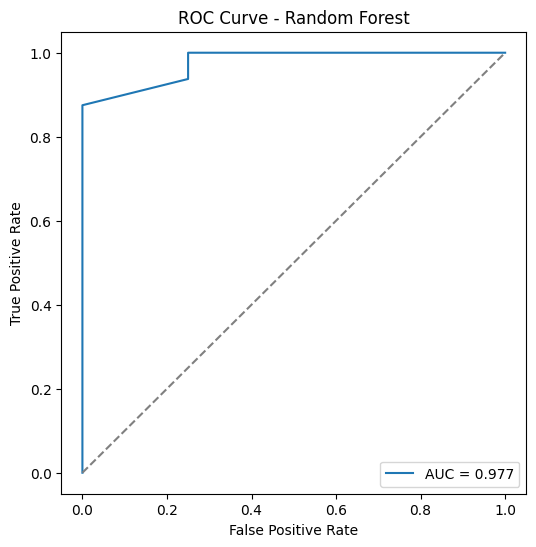

AUC: 0.9765625


In [24]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probability predictions
y_prob =  model.predict_proba(X_test)

# If binary classification (Smoker vs NonSmoker)
# adjust class index if needed
positive_class_index = list(model.classes_).index("Smoker")

y_score = y_prob[:, positive_class_index]

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_score, pos_label="Smoker")
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],"--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

print("AUC:", roc_auc)

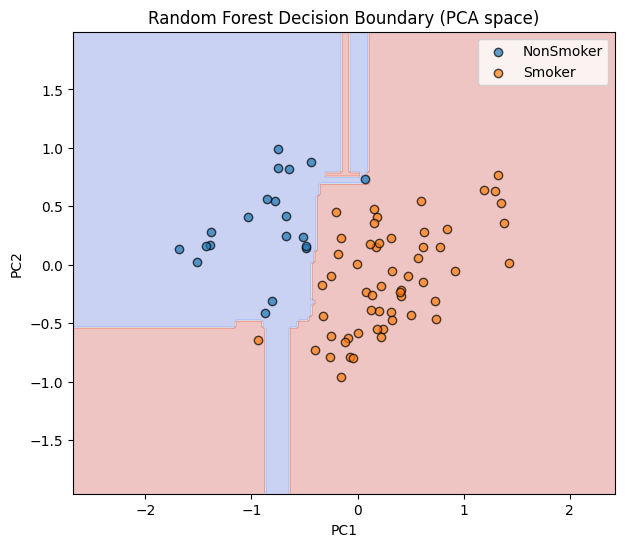

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_num = le.fit_transform(y_train)

pca_2d = PCA(n_components=2, random_state=42)

X_train_pca = pca_2d.fit_transform(X_train)
X_test_pca = pca_2d.transform(X_test)

rf_pca = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight='balanced',max_features='sqrt')

import numpy as np

x_min, x_max = X_train_pca[:,0].min() - 1, X_train_pca[:,0].max() + 1
y_min, y_max = X_train_pca[:,1].min() - 1, X_train_pca[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

rf_pca.fit(X_train_pca, y_train_num)

Z = rf_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,6))

plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")

colors = {'Smoker': 'red', 'NonSmoker': 'green'}

for label in np.unique(y_train):
    idx = y_train == label
    plt.scatter(
        X_train_pca[idx, 0],
        X_train_pca[idx, 1],
        label=label,
        edgecolor='k',
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Random Forest Decision Boundary (PCA space)")
plt.legend()
plt.show()

# SHAP

/lnet/aic/personal/brocekp/bioinformatika/bioinformatika/venv_bioinformatika/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


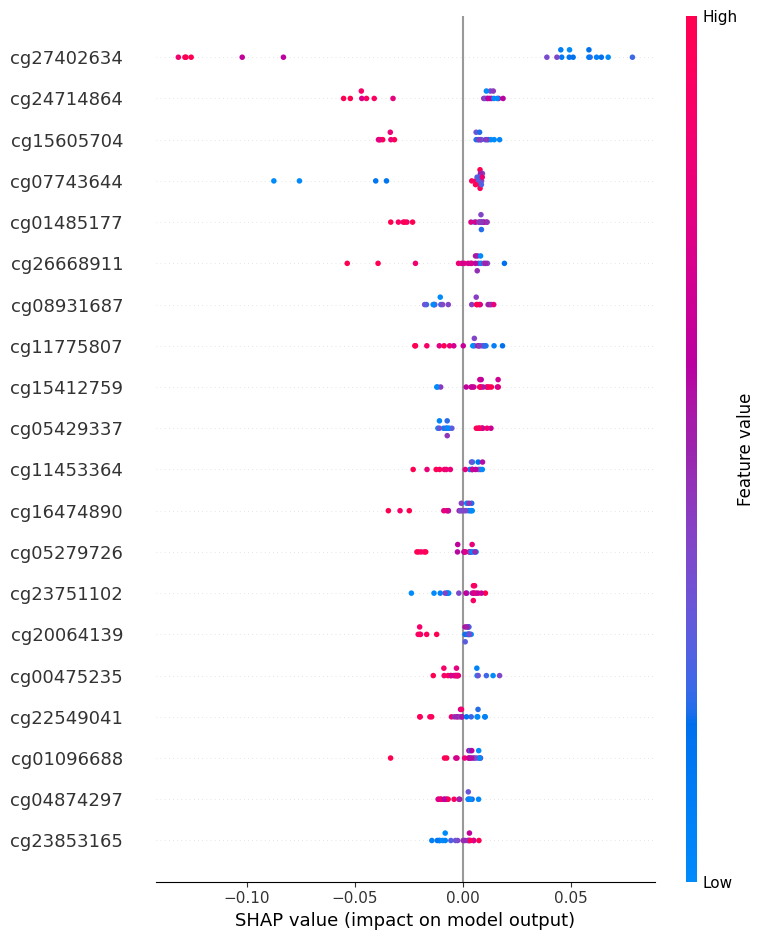

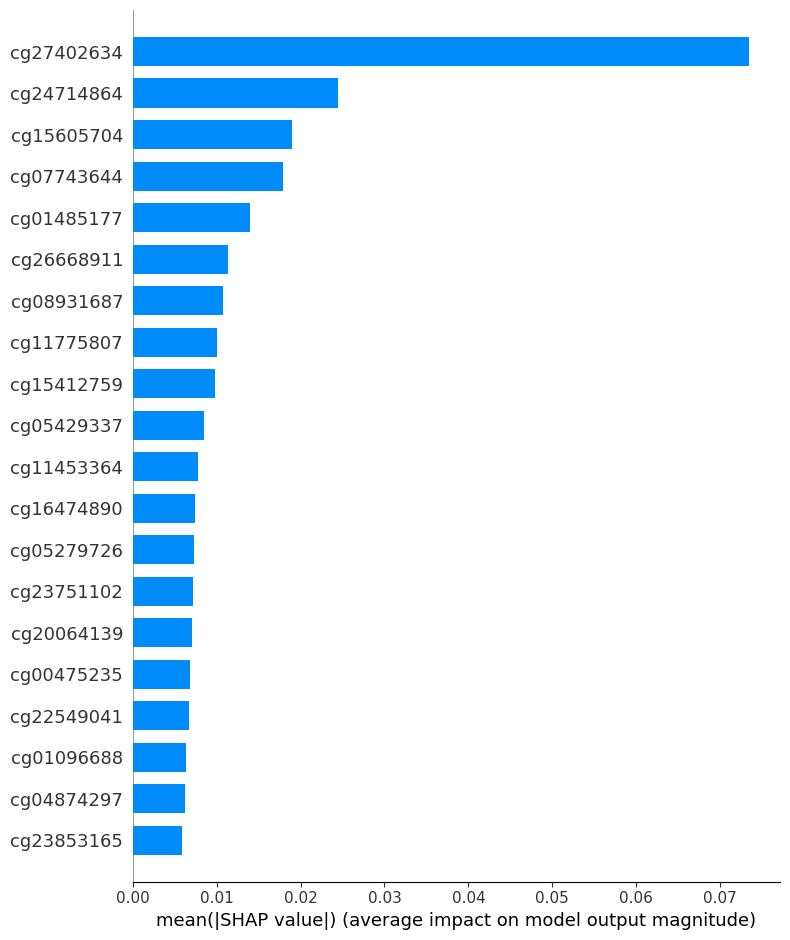

           CpG  mean_abs_SHAP
34  cg27402634       0.073461
36  cg24714864       0.024513
88  cg15605704       0.019011
64  cg07743644       0.017913
72  cg01485177       0.014026
83  cg26668911       0.011352
33  cg08931687       0.010760
43  cg11775807       0.010001
90  cg15412759       0.009749
91  cg05429337       0.008530
30  cg11453364       0.007820
26  cg16474890       0.007369
9   cg05279726       0.007291
13  cg23751102       0.007191
86  cg20064139       0.007069
50  cg00475235       0.006766
51  cg22549041       0.006704
21  cg01096688       0.006337
69  cg04874297       0.006275
6   cg23853165       0.005896


In [26]:
X_train = X_train_kbest.copy()
X_test = X_test_kbest.copy()

import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

selected_features = X_train_filtered.columns[selector.get_support()]

#print(type(shap_values))
#print(np.array(shap_values).shape)

shap_values_smoker = shap_values[:,:,1]

shap.summary_plot(
    shap_values_smoker,
    X_test,
    feature_names=selected_features
)

shap.summary_plot(
    shap_values_smoker,
    X_test,
    feature_names=selected_features,
    plot_type="bar"
)

#mean_abs_shap = np.abs(shap_values[1]).mean(axis=0)
mean_abs_shap = np.abs(shap_values_smoker).mean(axis=0)

shap_df = pd.DataFrame({
    "CpG": selected_features,
    "mean_abs_SHAP": mean_abs_shap
})

shap_df = shap_df.sort_values(
    "mean_abs_SHAP",
    ascending=False
)

print(shap_df.head(20))

In [27]:
!pip install methylprep

In [28]:
from methylprep.files import Manifest

manifest = Manifest(array_type='epic')

manifest.data_frame.head()


manifest.data_frame.loc[
    manifest.data_frame.index == "cg27402634"
]

,AddressA_ID,AddressB_ID,Infinium_Design_Type,Color_Channel,CHR,MAPINFO,Strand,Genome_Build,OLD_CHR,OLD_MAPINFO,OLD_Strand,OLD_Genome_Build,probe_type
IlmnID,,,,,,,,,,,,,
cg27402634,79773354,<NA>,II,NaN,3,156819071.0,R,hg38,3,156536860.0,R,hg19,II


In [29]:
from methylprep.files import Manifest

manifest = Manifest(array_type='epic')

manifest.data_frame.head()


,AddressA_ID,AddressB_ID,Infinium_Design_Type,Color_Channel,CHR,MAPINFO,Strand,Genome_Build,OLD_CHR,OLD_MAPINFO,OLD_Strand,OLD_Genome_Build,probe_type
IlmnID,,,,,,,,,,,,,
cg07881041,85713262,<NA>,II,NaN,19,5236005.0,F,hg38,19,5236016.0,F,hg19,II
cg18478105,46761277,86644198,I,Grn,20,63216298.0,F,hg38,20,61847650.0,F,hg19,I
cg23229610,21717843,<NA>,II,NaN,1,6781065.0,F,hg38,1,6841125.0,F,hg19,II
cg03513874,29622133,<NA>,II,NaN,2,197438742.0,R,hg38,2,198303466.0,R,hg19,II
cg09835024,16745152,81631976,I,Red,X,24054523.0,F,hg38,X,24072640.0,F,hg19,I


# KNN

In [30]:
X_train = X_train_kbest.copy()
X_test = X_test_kbest.copy()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)


from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt

scaler = StandardScaler()

# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)
X_train_scaled = X_train
X_test_scaled = X_test

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train_enc)

y_pred = knn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test_enc, y_pred))
print(classification_report(y_test_enc, y_pred))

Accuracy: 0.8
              precision    recall  f1-score   support

           0       0.50      0.25      0.33         4
           1       0.83      0.94      0.88        16

    accuracy                           0.80        20
   macro avg       0.67      0.59      0.61        20
weighted avg       0.77      0.80      0.77        20



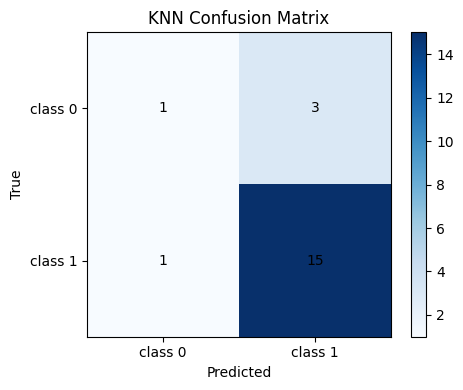

In [31]:
cm = confusion_matrix(y_test_enc, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("KNN Confusion Matrix")
plt.colorbar()

classes = ["class 0", "class 1"]

plt.xticks([0, 1], classes)
plt.yticks([0, 1], classes)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 color="black")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

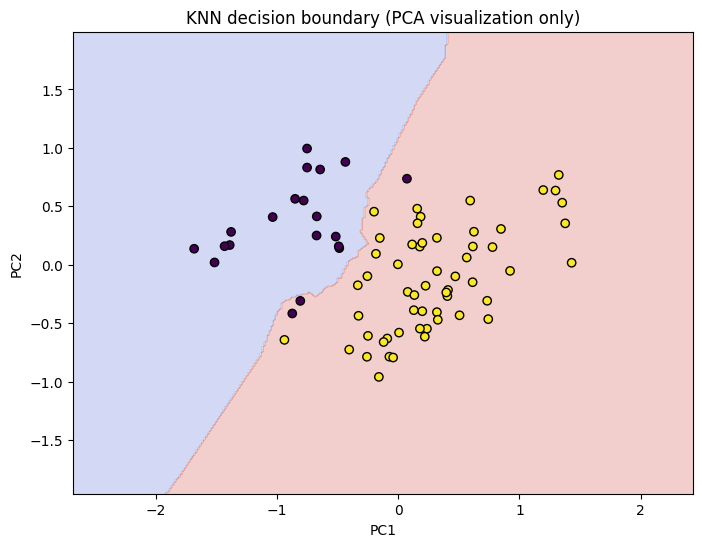

In [32]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_train_2d = pca.fit_transform(X_train_scaled)
X_test_2d = pca.transform(X_test_scaled)

knn_vis = KNeighborsClassifier(n_neighbors=5)
knn_vis.fit(X_train_2d, y_train_enc)


import numpy as np

x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.column_stack([xx.ravel(), yy.ravel()])
grid = grid.astype(float)

Z = knn_vis.predict(grid)
Z = np.asarray(Z, dtype=float).reshape(xx.shape)

plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")

plt.scatter(
    X_train_2d[:, 0],
    X_train_2d[:, 1],
    c=y_train_enc,
    edgecolor="k"
)

plt.title("KNN decision boundary (PCA visualization only)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


# SVM

Without rbf kernell because it would overfit probably

In [33]:
X_train = X_train_kbest.copy()
X_test = X_test_kbest.copy()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)
X_train_scaled = X_train
X_test_scaled = X_test

In [35]:
from sklearn.svm import SVC

svm = SVC(kernel="linear", C=1.0)

svm.fit(X_train_scaled, y_train_enc)

y_pred = svm.predict(X_test_scaled)

In [36]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

print("Accuracy:", accuracy_score(y_test_enc, y_pred))
print(classification_report(y_test_enc, y_pred))

Accuracy: 0.8
              precision    recall  f1-score   support

           0       0.50      0.25      0.33         4
           1       0.83      0.94      0.88        16

    accuracy                           0.80        20
   macro avg       0.67      0.59      0.61        20
weighted avg       0.77      0.80      0.77        20



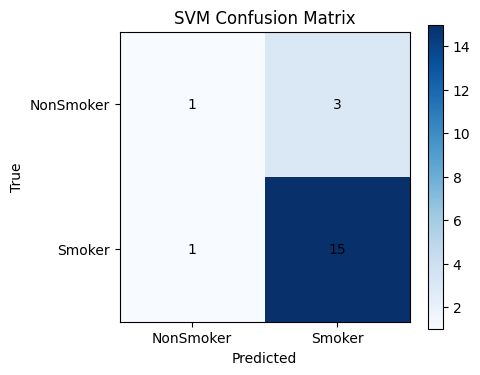

In [37]:
cm = confusion_matrix(y_test_enc, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.colorbar()

labels = le.classes_

plt.xticks([0, 1], labels)
plt.yticks([0, 1], labels)

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center", color="black")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

In [38]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_train_2d = pca.fit_transform(X_train_scaled)
X_test_2d = pca.transform(X_test_scaled)

svm_vis = SVC(kernel="linear", C=1.0)
svm_vis.fit(X_train_2d, y_train_enc)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


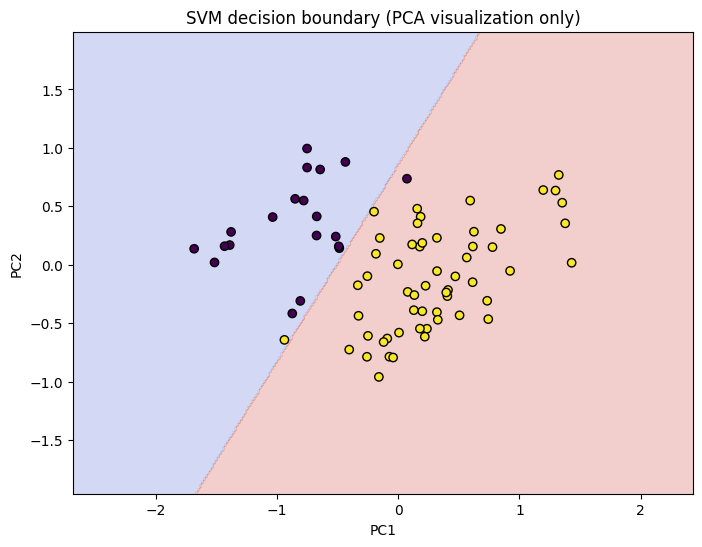

In [39]:
import numpy as np

x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()].astype(float)

Z = svm_vis.predict(grid).astype(float)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")

plt.scatter(
    X_train_2d[:, 0],
    X_train_2d[:, 1],
    c=y_train_enc,
    edgecolor="k"
)

plt.title("SVM decision boundary (PCA visualization only)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Most important features

In [40]:
X_train = X_train_kbest.copy()
X_test = X_test_kbest.copy()

from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)

sfs = SequentialFeatureSelector(
    model,
    n_features_to_select=10,
    direction="forward",
    scoring="accuracy",
    cv=3 
)


sfs.fit(X_train, y_train)

# Print most important features
selected_features = sfs.get_support(indices=True)
print("Selected feature indices:", selected_features)
print("Selected feature names:", X_train.columns[selected_features])

Selected feature indices: [ 0  1  2  3  4  7 21 24 34 36]
Selected feature names: Index(['cg12268888', 'cg04474990', 'cg08913726', 'cg06369090', 'cg04004205',
       'cg13141983', 'cg01096688', 'cg11739758', 'cg27402634', 'cg24714864'],
      dtype='str', name='ID_REF')


# KMeans on smokers

In [41]:
X_train = X_train_kbest[y_train == "Smoker"]
X_test = X_test_kbest[y_test == "Smoker"]
X_train = pd.concat([X_train, X_test], axis=0)

# import KMeans
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, init="k-means++", random_state=42)

clusters = kmeans.fit_predict(X_train)

unique, counts = np.unique(clusters, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Cluster {u}: {c} samples")


Cluster 0: 36 samples
Cluster 1: 36 samples


Cluster 0: 36 samples
Cluster 1: 36 samples


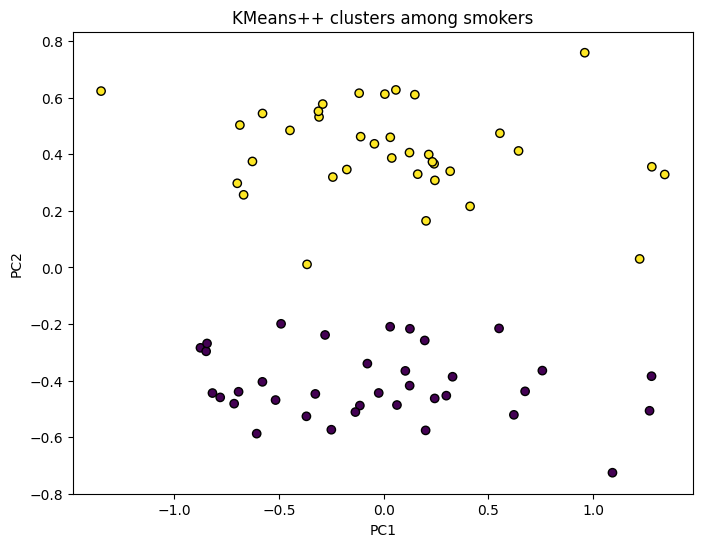

In [42]:
X_train = X_train_kbest[y_train == "Smoker"]
X_test = X_test_kbest[y_test == "Smoker"]
X_train = pd.concat([X_train, X_test], axis=0)

# import KMeans
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, init="k-means++", random_state=42)

clusters = kmeans.fit_predict(X_train)

unique, counts = np.unique(clusters, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Cluster {u}: {c} samples")


from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_smokers_2d = pca.fit_transform(X_train)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_smokers_2d[:, 0],
    X_smokers_2d[:, 1],
    c=clusters,
    edgecolor="k"
)

plt.title("KMeans++ clusters among smokers")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [43]:
print("ORI JE KOKOT skurveny picus")

ORI JE KOKOT skurveny picus
